# LSTM Benchmark

## 1. 准备 IREE VM Module

### 正向函数

In [1]:
%run nelli_lstm_objective.py
forward = str(module)

### 反向函数

#### CAPI

<span style="color: #f56c6c"> bug: capi 和 nabla-opt 输出不同 </span>

```python
import ctypes
lib = ctypes.cdll.LoadLibrary("./libNablaCAPI.so")
lib.backward.argstype = [ctypes.c_char_p]
lib.backward.restype = ctypes.c_char_p
backward = lib.backward(forward.encode("utf-8")).decode("utf-8") # capi 和 nabla-opt 的输出结果不同
assert "dlstm_objective" in backward
```

#### Nabla-opt

In [2]:
import subprocess
import os

nabla_opt = "/home/ccy/nabla-build/bin/nabla-opt"
nabla_opt = subprocess.Popen([nabla_opt, "forward.mlir", "--backward"], stdout=subprocess.PIPE)
with open("forward.mlir", "w") as f:
    f.write(forward)

backward = nabla_opt.stdout.read()
nabla_opt.wait()

os.remove("forward.mlir")

### 编译 VM Module

In [3]:
import iree.compiler
import iree.runtime

def compile_str(mlir):
    binary = iree.compiler.compile_str(
        mlir, input_type="tosa", target_backends=["llvm-cpu"]
    )
    return iree.runtime.load_vm_flatbuffer(binary, backend="llvm-cpu")

module = compile_str(backward)

## 2. 验证 IR 有效性

### 准备数据

<span style="color: #f56c6c"> TODO: 加载 [ADBench data](https://github.com/microsoft/ADBench/tree/master/data) </span>

In [4]:
%run torch_lstm_objective.py

torch_args = [torch.randn(x) for x in [(4, 56), (3, 14), (4, 14), (32, 14)]]
iree_args = list(map(lambda x : x.numpy(), torch_args))

for arg in torch_args:
    arg.requires_grad = True

### 正向结果一致性

In [5]:
import numpy as np

torch_res = lstm_objective(*torch_args)
iree_res = module["lstm_objective"](*iree_args)

assert np.allclose(torch_res.detach().numpy(), iree_res.to_host())

### 反向结果一致性

In [6]:
torch_grads = torch.autograd.grad(torch_res, torch_args, torch.ones_like(torch_res), retain_graph=True)
iree_grads = module["dlstm_objective"](*iree_args, torch.ones_like(torch_res).numpy())

for torch_grad, iree_grad in zip(torch_grads, iree_grads):
    assert np.allclose(torch_grad.detach().numpy(), iree_grad.to_host())

## 3. Benchmark 测试

### Torch

In [7]:
from torch.utils import benchmark

torch_forward = benchmark.Timer(
    stmt="lstm_objective(*torch_args)",
    globals=globals(),
    num_threads=16
).timeit(100)

torch_backward = benchmark.Timer(
    stmt="torch.autograd.grad(torch_res, torch_args, torch.ones_like(torch_res), retain_graph=True)",
    globals=globals(),
    num_threads=16
).timeit(100)

No CUDA runtime is found, using CUDA_HOME='/usr/local/cuda'


### IREE

<span style="color: #f56c6c"> `benchmark_module` not work </span>

```python
from iree.runtime import benchmark_module

np.save("iree_args.npy", iree_args)

iree_forward = benchmark_module(
    module.vm_module, entry_functiong="lstm_objective", inputs="@iree_args.npy", benchmark_repetition=10
) # not work
```

In [8]:
iree_forward = benchmark.Timer(
    stmt="module['lstm_objective'](*iree_args)",
    globals=globals(),
    num_threads=16
).timeit(100)

iree_backward = benchmark.Timer(
    stmt="module['dlstm_objective'](*iree_args, torch.ones_like(torch_res).numpy())",
    globals=globals(),
    num_threads=16
).timeit(100)

## 4. 结果可视化

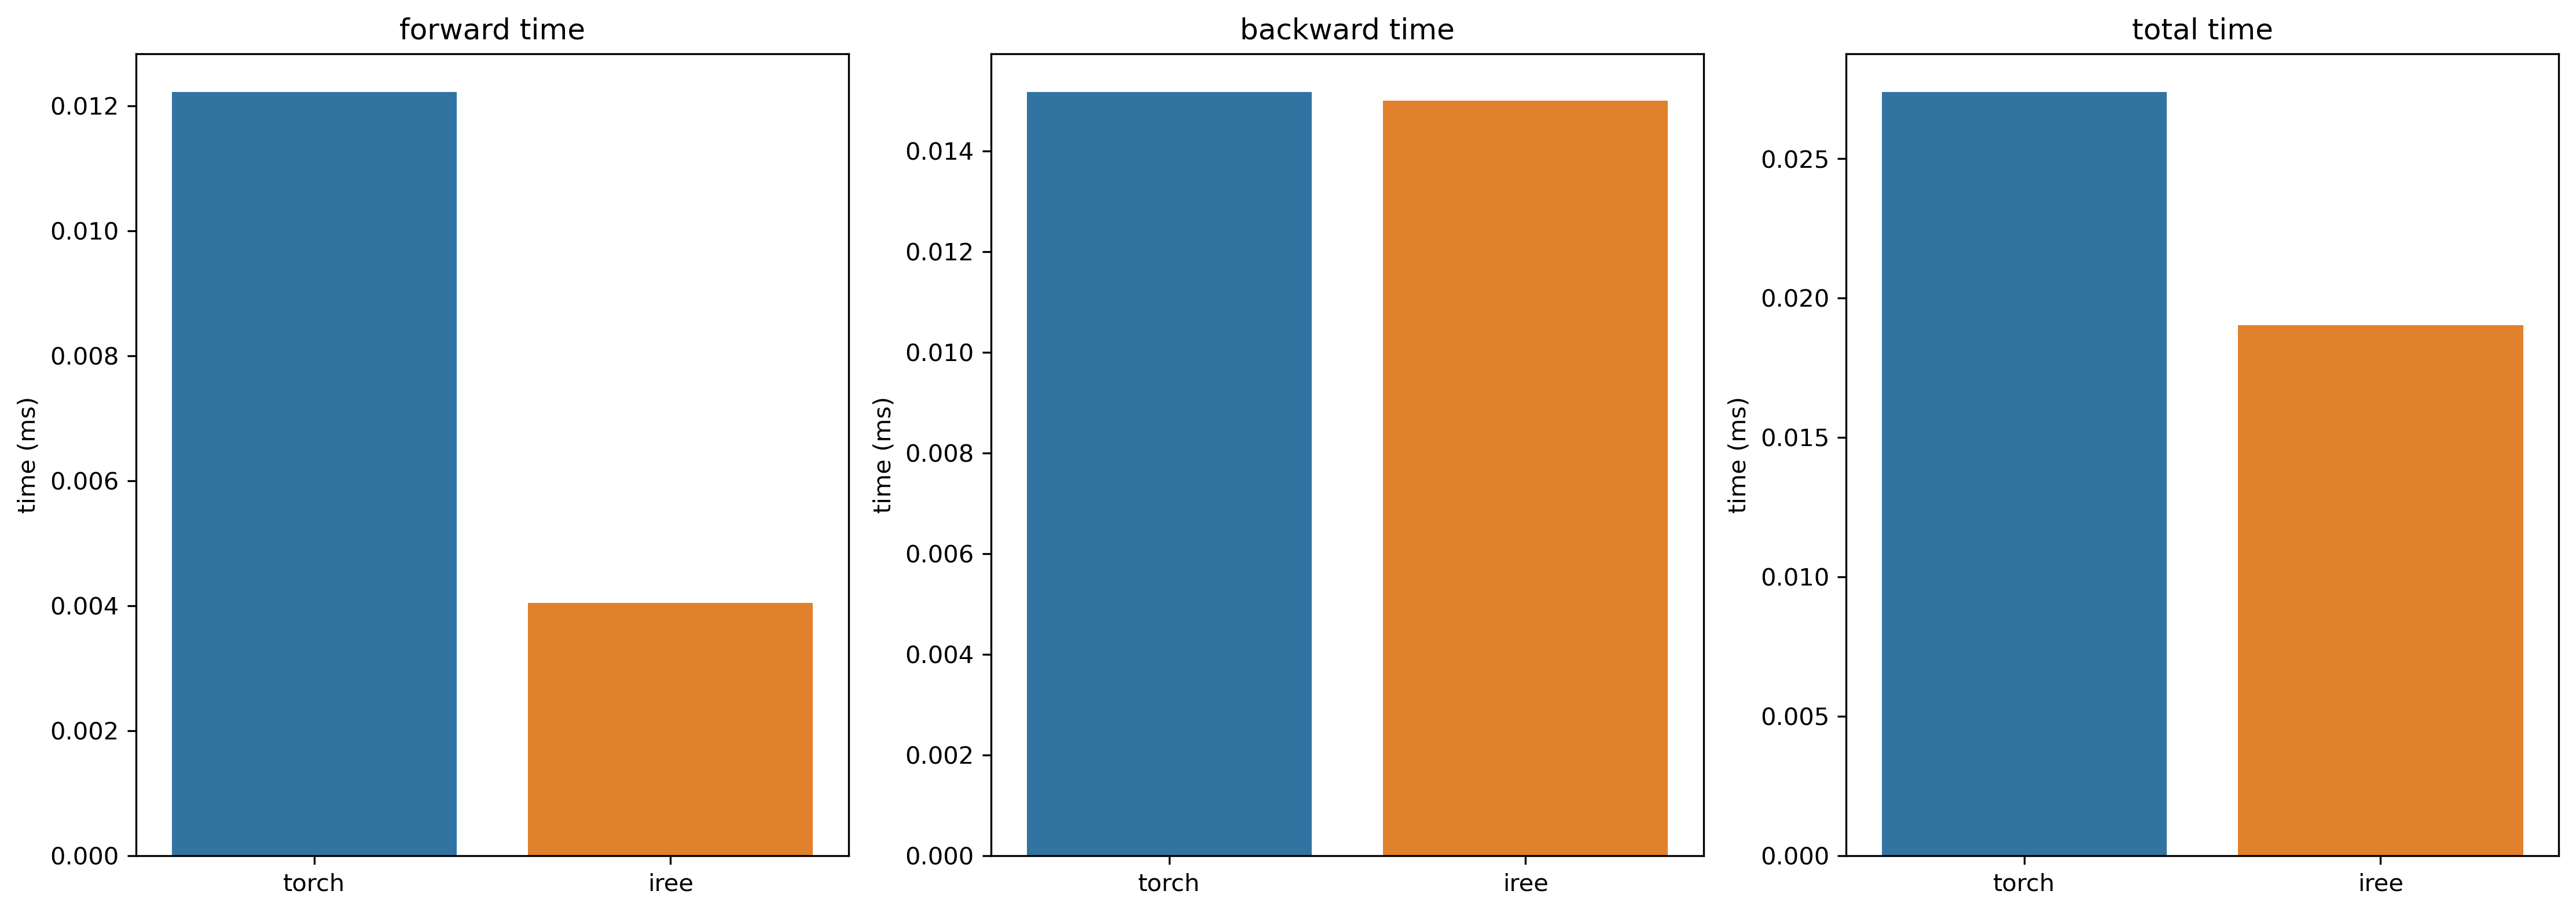

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
from pandas import DataFrame

plt.rcParams["figure.dpi"] = 300

fig, (ax0, ax1, ax2) = plt.subplots(ncols=3, figsize=(18, 6))
sns.barplot(DataFrame({
    "torch": [torch_forward.mean],
    "iree": [iree_forward.mean]
}), ax=ax0)
ax0.set_title("forward time")

sns.barplot(DataFrame({
    "torch": [torch_backward.mean],
    "iree": [iree_backward.mean]
}), ax=ax1)
ax1.set_title("backward time")

sns.barplot(DataFrame({
    "torch": [torch_backward.mean + torch_forward.mean],
    "iree": [iree_backward.mean + iree_forward.mean]
}), ax=ax2)
ax2.set_title("total time")

for ax in [ax0, ax1, ax2]:
    ax.set_ylabel("time (ms)")